# 04 — Serie temporal: pronóstico semanal de cortes (Panel 3)

**Entrada**: `data/processed/serie_semanal.csv` (formato largo: semana × serie).
**Salidas**: `data/processed/metricas_series.csv` y
`data/processed/pronostico_semanal.csv` (insumos del Panel 3 del dashboard).

Obligaciones del Panel 3: serie con tendencia, comparación de modelos
(media móvil → suavizado exponencial → ARIMA), **MAPE y RMSE reportados** para
cada uno, y **pronóstico ≥4 periodos** con intervalo. El backtesting usa corte
temporal (nunca split aleatorio en series).

In [1]:
SERIE_OBJETIVO = "TOTAL"   # también puede pronosticarse un distrito top-8
SEMANAS_TEST = 12          # holdout final para comparar modelos
HORIZONTE = 8              # semanas a pronosticar (>= 4 exigidas)
VENTANA_MA = 4             # ventana de la media móvil baseline
PERIODO_ESTACIONAL = 52    # semanas por año
MARGEN_EMPATE_MAPE = 1.0   # pts de MAPE: si un modelo estadístico queda a menos de
                           # esto del baseline plano, se prefiere el estadístico

# Ventana de análisis: los bordes del registro están incompletos (ver sección 1)
FECHA_INICIO_SERIE = "2019-06-24"  # antes: 3 y 1 eventos/semana (arranque del registro)
FECHA_FIN_SERIE = "2024-04-15"     # después: 67 y 8 eventos (corte de extracción del dataset)

In [2]:
import itertools
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style="whitegrid")

RAIZ = Path.cwd() if (Path.cwd() / "data" / "processed").exists() else Path.cwd().parent
RUTA_PROCESSED = RAIZ / "data" / "processed"

serie_larga = pd.read_csv(RUTA_PROCESSED / "serie_semanal.csv", parse_dates=["semana"])
tabla = serie_larga.pivot(index="semana", columns="distrito", values="n_cortes")
print("semanas:", tabla.shape[0], "| series:", list(tabla.columns))

semanas: 257 | series: ['ATE', 'AYACUCHO', 'LA MOLINA', 'SAN JUAN DE LURIGANCHO', 'SAN JUAN DE MIRAFLORES', 'TOTAL', 'VENTANILLA', 'VILLA EL SALVADOR', 'VILLA MARIA DEL TRIUNFO']


## 1. Preparación: recorte de bordes incompletos

Los bordes de la serie no reflejan la realidad del servicio sino la **cobertura
del registro**:

- **Inicio**: las semanas 2019-06-10 y 2019-06-17 tienen 3 y 1 eventos — el
  registro SUNASS recién arrancaba (y la primera semana calendario está además
  incompleta: los datos crudos empiezan un martes).
- **Final**: 2024-04-22 y 2024-04-29 caen a 67 y 8 eventos frente a una mediana
  2023 de ~204 — es el corte de extracción del dataset (termina el 2024-05-07),
  no una mejora real del servicio.

Entrenar o evaluar sobre esos bordes sesga los modelos y **dispara el MAPE**
(se divide por valores cercanos a cero): con los bordes dentro del holdout el
MAPE superaba el 260% en los 3 modelos. La ventana de análisis queda fijada por
las constantes `FECHA_INICIO_SERIE` / `FECHA_FIN_SERIE`.

In [3]:
print("bordes de la serie cruda (evidencia del recorte):")
print(pd.concat([tabla[SERIE_OBJETIVO].head(3), tabla[SERIE_OBJETIVO].tail(3)]).to_string())

tabla = tabla.loc[FECHA_INICIO_SERIE:FECHA_FIN_SERIE]
tabla = tabla.asfreq("W-MON")  # frecuencia semanal explícita (lunes de cada semana)

serie = tabla[SERIE_OBJETIVO].astype(float)
print(f"serie {SERIE_OBJETIVO}: {serie.index.min().date()} a {serie.index.max().date()}",
      f"| {len(serie)} semanas | min={serie.min():.0f} max={serie.max():.0f}")
assert serie.isna().sum() == 0, "la serie no debe tener huecos"
assert (serie > 0).all(), "MAPE requiere valores > 0"

bordes de la serie cruda (evidencia del recorte):
semana
2019-06-10     3
2019-06-17     1
2019-06-24    38
2024-04-22    67
2024-04-29     8
2024-05-06     1
serie TOTAL: 2019-06-24 a 2024-04-15 | 252 semanas | min=38 max=298


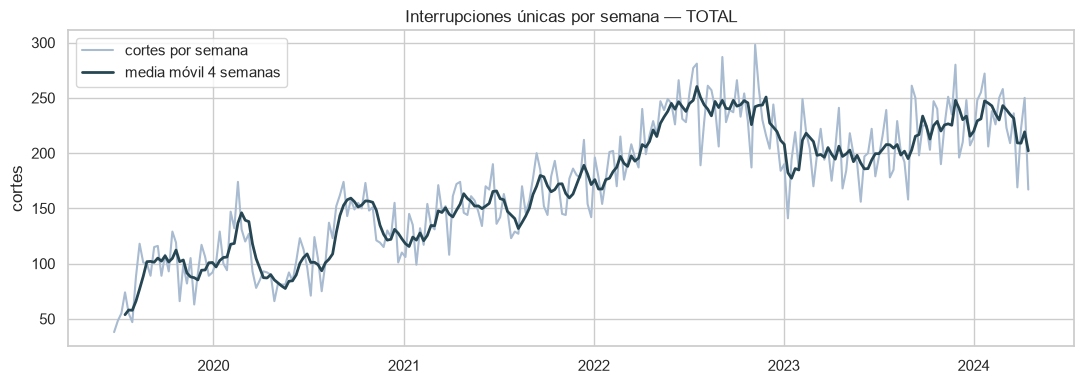

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(serie.index, serie.values, color="#a8bbd0", label="cortes por semana")
ax.plot(serie.index, serie.rolling(VENTANA_MA).mean(), color="#264653",
        linewidth=2, label=f"media móvil {VENTANA_MA} semanas")
ax.set_title(f"Interrupciones únicas por semana — {SERIE_OBJETIVO}")
ax.set_ylabel("cortes")
ax.legend()
plt.tight_layout()
plt.show()

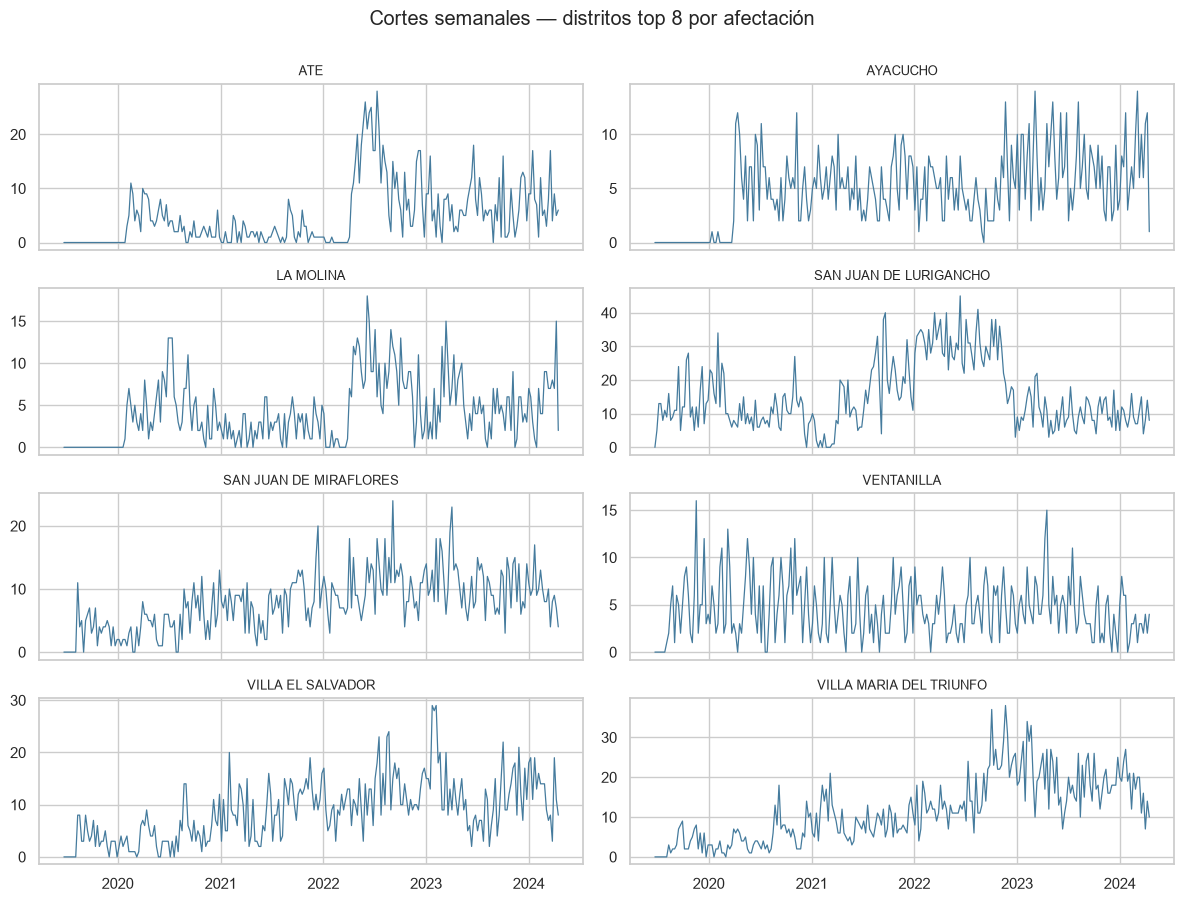

In [5]:
distritos = [c for c in tabla.columns if c != "TOTAL"]
fig, axes = plt.subplots(4, 2, figsize=(12, 9), sharex=True)
for ax, d in zip(axes.ravel(), distritos):
    ax.plot(tabla.index, tabla[d], color="#457b9d", linewidth=0.9)
    ax.set_title(d, fontsize=9)
plt.suptitle("Cortes semanales — distritos top 8 por afectación", y=1.0)
plt.tight_layout()
plt.show()

## 2. Estructura de la serie: descomposición y ACF/PACF

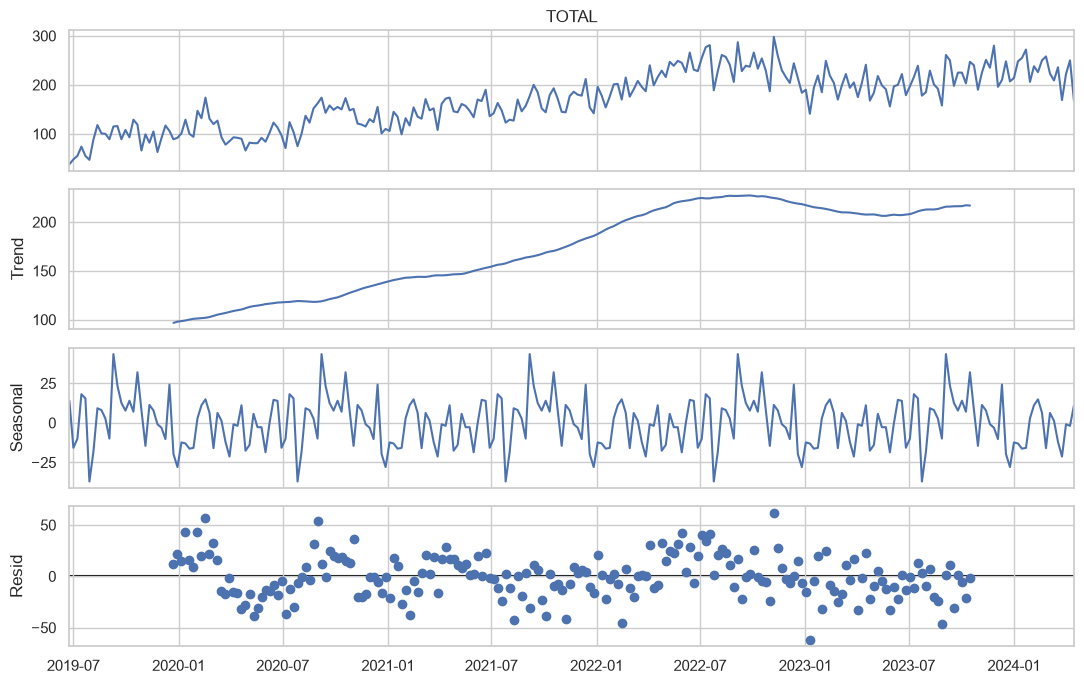

In [6]:
descomposicion = seasonal_decompose(serie, model="additive", period=PERIODO_ESTACIONAL)
fig = descomposicion.plot()
fig.set_size_inches(11, 7)
plt.tight_layout()
plt.show()

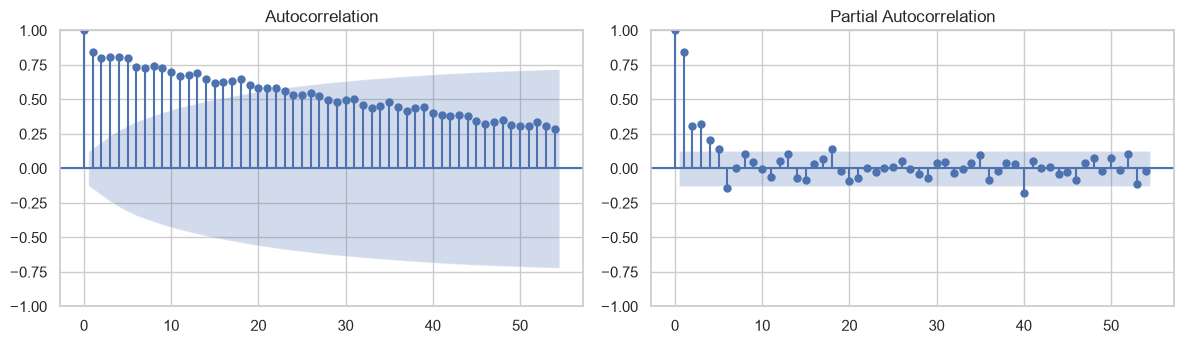

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
plot_acf(serie, lags=54, ax=axes[0])
plot_pacf(serie, lags=54, ax=axes[1], method="ywm")
plt.tight_layout()
plt.show()

## 3. Backtesting con corte temporal

Train = toda la serie menos las últimas `SEMANAS_TEST`; test = esas últimas
semanas. En series temporales **nunca** se hace split aleatorio: se evaluaría el
pasado con información del futuro.

In [8]:
train = serie.iloc[:-SEMANAS_TEST]
test = serie.iloc[-SEMANAS_TEST:]
print(f"train: {len(train)} semanas (hasta {train.index.max().date()})",
      f"| test: {len(test)} semanas")

train: 240 semanas (hasta 2024-01-22) | test: 12 semanas


In [9]:
# Pronóstico plano: el promedio de las últimas VENTANA_MA semanas del train.
# Es la vara mínima: cualquier modelo serio debe superarla.
pron_ma = pd.Series(train.tail(VENTANA_MA).mean(), index=test.index)

In [10]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ajuste_hw = ExponentialSmoothing(
        train, trend="add", seasonal="add",
        seasonal_periods=PERIODO_ESTACIONAL,
        initialization_method="estimated").fit()
pron_hw = ajuste_hw.forecast(SEMANAS_TEST)

In [11]:
resultados_aic = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for p, d, q in itertools.product(range(3), range(2), range(3)):
        try:
            aic = ARIMA(train, order=(p, d, q)).fit().aic
            resultados_aic.append({"orden": (p, d, q), "aic": aic})
        except Exception:
            continue

tabla_aic = pd.DataFrame(resultados_aic).sort_values("aic").head(5)
print("Top 5 ordenes por AIC:")
print(tabla_aic.to_string(index=False))
MEJOR_ORDEN = tabla_aic.iloc[0]["orden"]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ajuste_arima = ARIMA(train, order=MEJOR_ORDEN).fit()
pron_arima = ajuste_arima.forecast(SEMANAS_TEST)

Top 5 ordenes por AIC:
    orden         aic
(2, 1, 1) 2221.624312
(2, 1, 2) 2222.138499
(1, 1, 2) 2224.522136
(0, 1, 1) 2225.321017
(0, 1, 2) 2226.267674


In [12]:
pronosticos = {
    f"Media movil ({VENTANA_MA} sem)": pron_ma,
    "Suavizado exponencial (HW)": pron_hw,
    f"ARIMA {MEJOR_ORDEN}": pron_arima,
}
filas = []
for nombre, pron in pronosticos.items():
    filas.append({
        "modelo": nombre,
        "MAPE_pct": mean_absolute_percentage_error(test, pron) * 100,
        "RMSE": root_mean_squared_error(test, pron),
    })
metricas = pd.DataFrame(filas).set_index("modelo").sort_values("MAPE_pct")
metricas.round(2)

,MAPE_pct,RMSE
modelo,,
Media movil (4 sem),14.95,38.46
"ARIMA (2, 1, 1)",15.13,39.38
Suavizado exponencial (HW),23.20,54.43


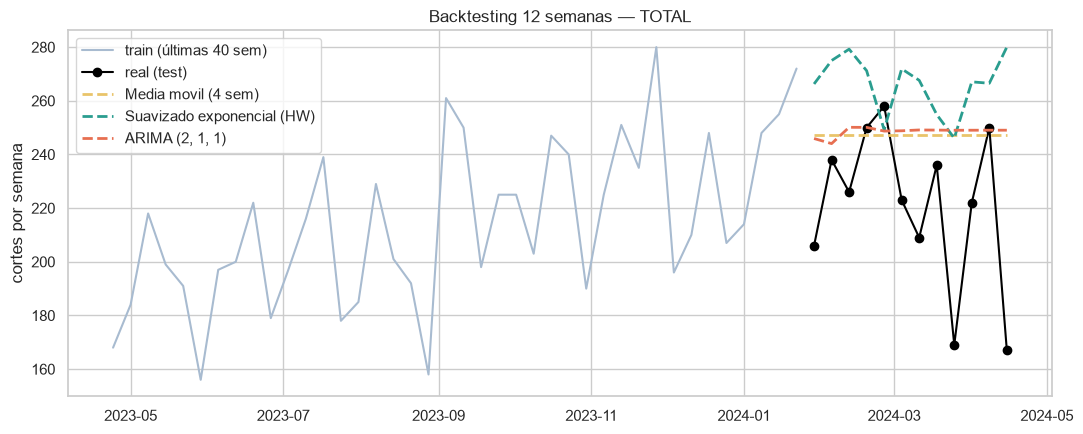

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(train.index[-40:], train.values[-40:], color="#a8bbd0", label="train (últimas 40 sem)")
ax.plot(test.index, test.values, "o-", color="black", label="real (test)")
colores = ["#e9c46a", "#2a9d8f", "#e76f51"]
for (nombre, pron), color in zip(pronosticos.items(), colores):
    ax.plot(pron.index, pron.values, "--", color=color, linewidth=2, label=nombre)
ax.set_title(f"Backtesting {SEMANAS_TEST} semanas — {SERIE_OBJETIVO}")
ax.set_ylabel("cortes por semana")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura**: la media móvil logra MAPE **14.9%** y ARIMA(2,1,1) **15.1%** — un
**empate técnico** (0.2 pts). Que un pronóstico plano compita así dice algo real:
en el último año la serie es estable alrededor de ~200-250 cortes/semana, sin
tendencia fuerte. Holt-Winters queda tercero (23.2%): la estacionalidad anual
estimada con solo ~4.6 ciclos añade más varianza que señal.

**Regla de desempate** (constante `MARGEN_EMPATE_MAPE`): si un modelo estadístico
queda a menos de 1 punto de MAPE del baseline plano, se prefiere el estadístico —
entrega intervalos de confianza fundamentados y reacciona a cambios de nivel,
mientras que la media móvil es una constante sin estructura. Esto responde
directamente la pregunta típica "¿un MAPE de ~15% es aceptable?": sí, porque ni
el baseline ingenuo puede bajar de ~15% — ese es el piso de ruido de la serie.

## 4. Pronóstico final ≥4 semanas con intervalo de confianza

El mejor modelo se reajusta sobre la **serie completa** y pronostica
`HORIZONTE` semanas hacia adelante.

In [14]:
ganador = metricas.index[0]
if ganador.startswith("Media movil"):
    candidatos = metricas[~metricas.index.str.startswith("Media movil")]
    if candidatos["MAPE_pct"].iloc[0] - metricas["MAPE_pct"].iloc[0] <= MARGEN_EMPATE_MAPE:
        ganador = candidatos.index[0]
print("modelo ganador (MAPE + regla de desempate):", ganador)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    if ganador.startswith("ARIMA"):
        ajuste_full = ARIMA(serie, order=MEJOR_ORDEN).fit()
        prediccion = ajuste_full.get_forecast(HORIZONTE)
        pron_final = prediccion.predicted_mean
        ic = prediccion.conf_int(alpha=0.05)
        ic_inf, ic_sup = ic.iloc[:, 0], ic.iloc[:, 1]
    elif ganador.startswith("Suavizado"):
        ajuste_full = ExponentialSmoothing(
            serie, trend="add", seasonal="add",
            seasonal_periods=PERIODO_ESTACIONAL,
            initialization_method="estimated").fit()
        pron_final = ajuste_full.forecast(HORIZONTE)
        # HW no trae IC nativo: se aproxima con +-1.96 sigma de los residuos
        sigma = (serie - ajuste_full.fittedvalues).std()
        ic_inf, ic_sup = pron_final - 1.96 * sigma, pron_final + 1.96 * sigma
    else:
        nivel = serie.tail(VENTANA_MA).mean()
        indice_fut = pd.date_range(serie.index.max() + pd.Timedelta(weeks=1),
                                   periods=HORIZONTE, freq="W-MON")
        pron_final = pd.Series(nivel, index=indice_fut)
        sigma = serie.diff().std()
        ic_inf, ic_sup = pron_final - 1.96 * sigma, pron_final + 1.96 * sigma

pron_final = pron_final.clip(lower=0)
ic_inf = ic_inf.clip(lower=0)

modelo ganador (MAPE + regla de desempate): ARIMA (2, 1, 1)


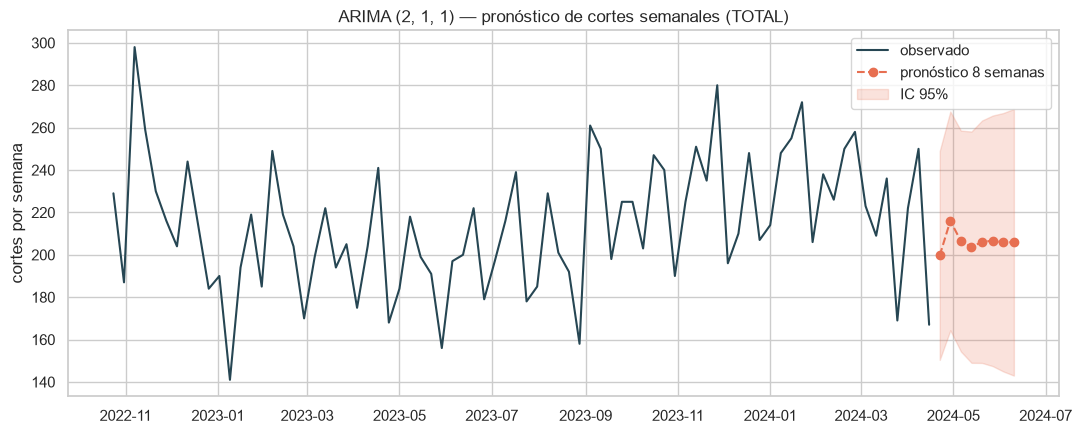

Pronostico:
            pronostico  ic_inferior  ic_superior
2024-04-22       199.7        150.4        248.9
2024-04-29       216.0        164.4        267.6
2024-05-06       206.5        154.4        258.6
2024-05-13       203.6        149.0        258.2
2024-05-20       206.2        149.0        263.4
2024-05-27       206.6        147.5        265.7
2024-06-03       205.9        145.0        266.9
2024-06-10       205.9        143.0        268.8


In [15]:
fig, ax = plt.subplots(figsize=(11, 4.5))
recorte = serie.tail(78)
ax.plot(recorte.index, recorte.values, color="#264653", label="observado")
ax.plot(pron_final.index, pron_final.values, "o--", color="#e76f51",
        label=f"pronóstico {HORIZONTE} semanas")
ax.fill_between(pron_final.index, ic_inf, ic_sup, color="#e76f51", alpha=0.2,
                label="IC 95%")
ax.set_title(f"{ganador} — pronóstico de cortes semanales ({SERIE_OBJETIVO})")
ax.set_ylabel("cortes por semana")
ax.legend()
plt.tight_layout()
plt.show()

print("Pronostico:")
print(pd.DataFrame({"pronostico": pron_final.round(1),
                    "ic_inferior": ic_inf.round(1),
                    "ic_superior": ic_sup.round(1)}).to_string())

In [16]:
metricas.round(3).to_csv(RUTA_PROCESSED / "metricas_series.csv")
salida_pron = pd.DataFrame({
    "semana": pron_final.index,
    "pronostico": pron_final.round(2).values,
    "ic_inferior": ic_inf.round(2).values,
    "ic_superior": ic_sup.round(2).values,
    "modelo": ganador,
})
salida_pron.to_csv(RUTA_PROCESSED / "pronostico_semanal.csv", index=False)
print("guardado: metricas_series.csv y pronostico_semanal.csv")

guardado: metricas_series.csv y pronostico_semanal.csv


## Conclusiones (material para el informe)

- Los bordes del registro estaban incompletos (semanas con 1-8 eventos): sin el
  recorte por ventana de análisis, el MAPE del backtest superaba el **260%**;
  con la serie limpia baja a ~15%. Complicación → resolución para el informe.
- Backtesting con corte temporal (12 semanas): media móvil 14.9%, ARIMA(2,1,1)
  15.1%, Holt-Winters 23.2% de MAPE (tabla `metricas_series.csv`).
- El empate técnico baseline-ARIMA indica una serie estable: un MAPE de ~15% es
  el piso de ruido semanal; el valor del modelo está en el intervalo de confianza
  y la reacción a cambios de nivel, no en ganar décimas de MAPE.
- Se pronostican `HORIZONTE` semanas con IC 95% (ARIMA por regla de desempate);
  el dashboard muestra MAPE/RMSE en métricas de cabecera (exigencia del profesor).